In [1]:
import tifffile
import os, glob
import numpy
import SimpleITK as sitk

from matplotlib import pyplot
from tiffwrapper import make_composite

path = "/home-local2/tmp"
files = glob.glob(os.path.join(path, "*.tif"))
print(files)


['/home-local2/tmp/xy_640nm.tif', '/home-local2/tmp/xy_475nm.tif', '/home-local2/tmp/xy_560nm.tif']


In [45]:
def command_iteration(method):
    """ Callback invoked when the optimization has an iteration """
    print(f"{method.GetOptimizerIteration():3} " + f"= {method.GetMetricValue():10.5f}")

def extract_translation(transform, reference_image=None):
    """
    Robustly extract a translation vector (tx, ty) from a transform.
    - If `transform` is a TranslationTransform -> returns its GetTranslation().
    - If `transform` is a CompositeTransform -> tries to find a Translation sub-transform.
    - Otherwise, if reference_image is provided, computes the effective translation
      at the image centre: mapped(center) - center (physical coords).
    - Raises ValueError if it cannot determine a translation.
    """
    # direct if transform is translation
    try:
        tr = transform.GetTranslation()  # works for TranslationTransform
        return tuple(tr)
    except Exception:
        pass

    # composite: look for a translation component
    try:
        n = transform.GetNumberOfTransforms()
    except Exception:
        n = 0

    for i in range(n):
        try:
            sub = transform.GetNthTransform(i)
            tr = sub.GetTranslation()
            return tuple(tr)
        except Exception:
            continue

    # fallback: compute displacement of image center if reference provided
    if reference_image is not None:
        # compute image center in physical coords
        center_index = (numpy.array(reference_image.GetSize()) - 1) / 2.0
        center_phys = reference_image.TransformContinuousIndexToPhysicalPoint(center_index.tolist())
        mapped = transform.TransformPoint(center_phys)
        disp = tuple(numpy.array(mapped) - numpy.array(center_phys))
        return disp

    raise ValueError("Could not extract translation from transform and no reference image provided.")



(2, 800, 800)


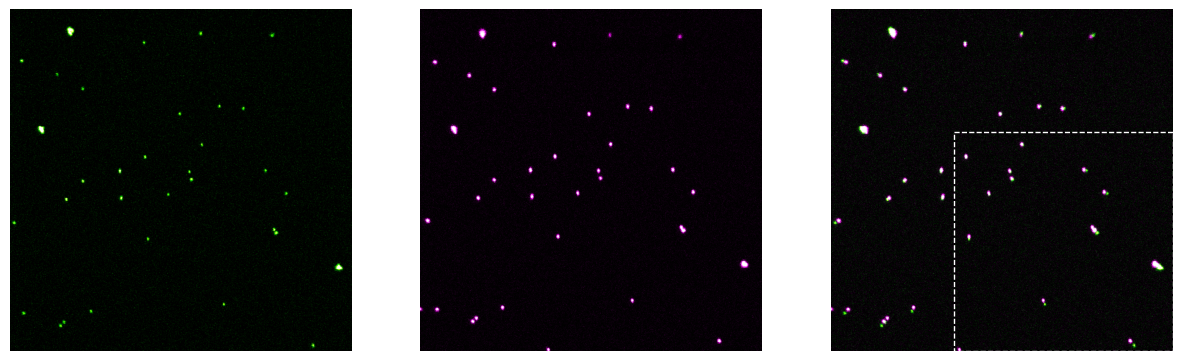

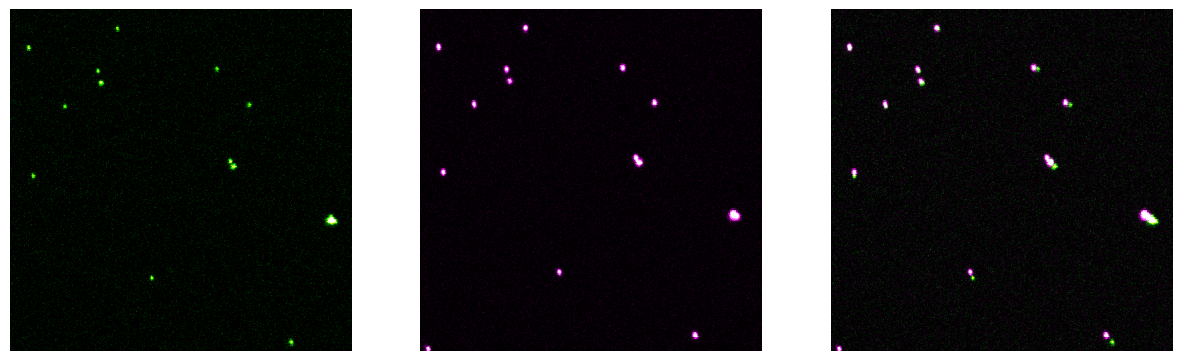

-------
itk::simple::TranslationTransform
 TranslationTransform (0x563b0c72f290)
   RTTI typeinfo:   itk::TranslationTransform<double, 2u>
   Reference Count: 2
   Modified Time: 66296
   Debug: Off
   Object Name: 
   Observers: 
     none
   Offset: [0, 0]

-------
itk::simple::AffineTransform
 AffineTransform (0x563b10378820)
   RTTI typeinfo:   itk::AffineTransform<double, 2u>
   Reference Count: 3
   Modified Time: 68323
   Debug: Off
   Object Name: 
   Observers: 
     none
   Matrix: 
     1.02171 0.00107734 
     -0.00321573 1.0254 
   Offset: [-9.09536, -8.84923]
   Center: [399.5, 399.5]
   Translation: [0.0079185, 0.0121072]
   Inverse: 
     0.978749 -0.00102833 
     0.00306944 0.975229 
   Singular: 0

Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Maximum number of iterations (300) exceeded.
 Iteration: 300
 Metric value: 0.0019208077543673404
(800, 800)


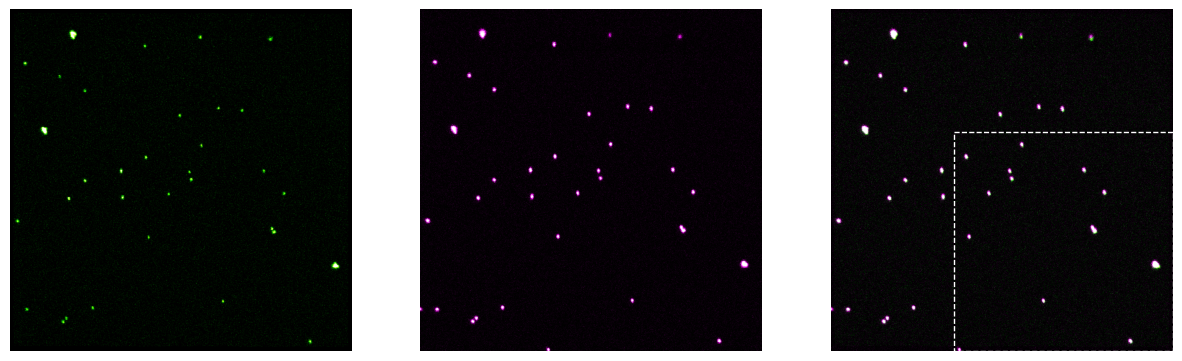

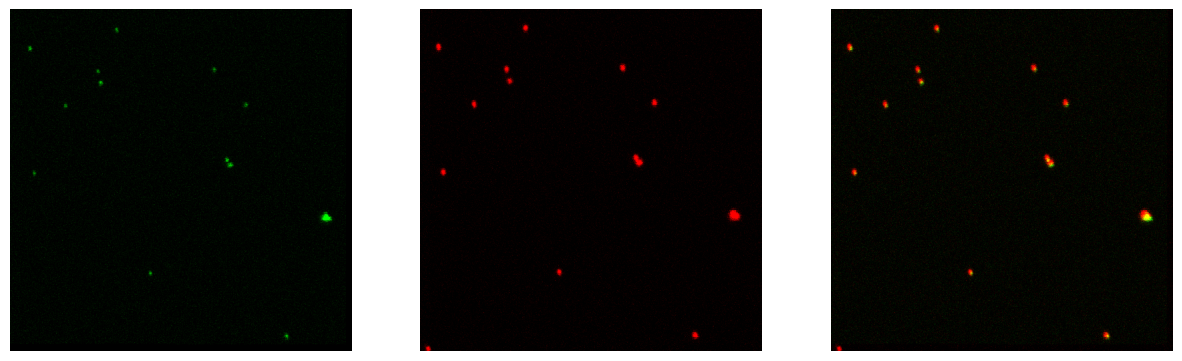

In [129]:
# import random
# random.shuffle(files)
# for file in files:
images = numpy.stack(
    [tifffile.imread(files[1]), tifffile.imread(files[0])]
).squeeze()
images = images.astype("float32")

print(images.shape)

cy, cx = numpy.array(images[0].shape) // 2
cy, cx = images[0].shape[0] - 256, images[0].shape[1] - 256
slc = tuple(
    slice(max(0, c - 256), min(s, c + 256)) for c, s in zip((cy, cx), images[0].shape)
)

from matplotlib import patches
rect = patches.Rectangle((slc[1].start, slc[0].start), slc[1].stop - slc[1].start, slc[0].stop - slc[0].start, linewidth=1, edgecolor='w', facecolor='none', linestyle='--')

fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(make_composite(images[0:1], ["Green Hot"], ranges=[(0, 1)]))
axes[1].imshow(make_composite(images[1:2], ["Magenta Hot"], ranges=[(0, 0.7)]))
axes[2].imshow(make_composite(images, ["Green Hot", "Magenta Hot"], ranges=[(0, 1), (0, 0.7)]))
axes[2].add_patch(rect)
for ax in axes:
    ax.axis('off')
pyplot.show()



fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(make_composite(images[0:1, slc[0], slc[1]], ["Green Hot"], ranges=[(0, 1)]))
axes[1].imshow(make_composite(images[1:2, slc[0], slc[1]], ["Magenta Hot"], ranges=[(0, 0.7)]))
axes[2].imshow(make_composite(images[:, slc[0], slc[1]], ["Green Hot", "Magenta Hot"], ranges=[(0, 1), (0, 0.7)]))
for ax in axes:
    ax.axis('off')
pyplot.show()

moving_image = sitk.GetImageFromArray(images[0])
fixed_image = sitk.GetImageFromArray(images[1])

R = sitk.ImageRegistrationMethod()
R.SetMetricAsMeanSquares()
R.SetOptimizerAsRegularStepGradientDescent(learningRate=4.0, minStep=1e-2, numberOfIterations=200)
R.SetInitialTransform(sitk.TranslationTransform(fixed_image.GetDimension()))
R.SetInterpolator(sitk.sitkLinear)
R.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(R))
tx1 = R.Execute(fixed_image, moving_image)
print("-------")
print(tx1)

tx = sitk.AffineTransform(2)
tx.SetMatrix((1.0, 0, 0, 1.0))
tx.SetTranslation(extract_translation(tx1, fixed_image))
center_index = (numpy.array(fixed_image.GetSize()) - 1) / 2.0
center_phys = fixed_image.TransformContinuousIndexToPhysicalPoint(center_index.tolist())
tx.SetCenter(center_phys)

R = sitk.ImageRegistrationMethod()
R.SetMetricAsMeanSquares()
R.SetOptimizerAsRegularStepGradientDescent(learningRate=0.1, minStep=1e-6, numberOfIterations=300)
R.SetInitialTransform(tx)
R.SetInterpolator(sitk.sitkLinear)
outTx = R.Execute(fixed_image, moving_image)

print("-------")
print(outTx)
print("Optimizer stop condition: {0}".format(R.GetOptimizerStopConditionDescription()))
print(" Iteration: {0}".format(R.GetOptimizerIteration()))
print(" Metric value: {0}".format(R.GetMetricValue()))

resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(fixed_image)
resampler.SetInterpolator(sitk.sitkNearestNeighbor)
resampler.SetTransform(outTx)
out = resampler.Execute(moving_image)

registered_image = sitk.GetArrayFromImage(out)
print(registered_image.shape)

tifffile.imwrite("/home-local2/tmp/registered.tif", registered_image.astype("float32"))

fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(make_composite(registered_image[None, ...], ["Green Hot"], ranges=[(0, 1)]))
axes[1].imshow(make_composite(images[1:2], ["Magenta Hot"], ranges=[(0, 0.7)]))
axes[2].imshow(make_composite(numpy.stack([registered_image, images[1]]), ["Green Hot", "Magenta Hot"], ranges=[(0, 1), (0, 0.7)]))

rect = patches.Rectangle((slc[1].start, slc[0].start), slc[1].stop - slc[1].start, slc[0].stop - slc[0].start, linewidth=1, edgecolor='w', facecolor='none', linestyle='--')
axes[2].add_patch(rect)
for ax in axes:
    ax.axis('off')
pyplot.show()

fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(make_composite(registered_image[slc[0], slc[1]][None, ...], ["green"], ranges=[(0, 1)]))
axes[1].imshow(make_composite(images[1:2, slc[0], slc[1]], ["red"], ranges=[(0, 0.7)]))
axes[2].imshow(make_composite(numpy.stack([registered_image[slc[0], slc[1]], images[1, slc[0], slc[1]]], axis=0), ["green", "red"], ranges=[(0, 1), (0, 0.7)]))
for ax in axes:
    ax.axis('off')
pyplot.show()


registered_image_copy = registered_image.copy()

# break

# Debug Translation Transform


(2, 800, 800)


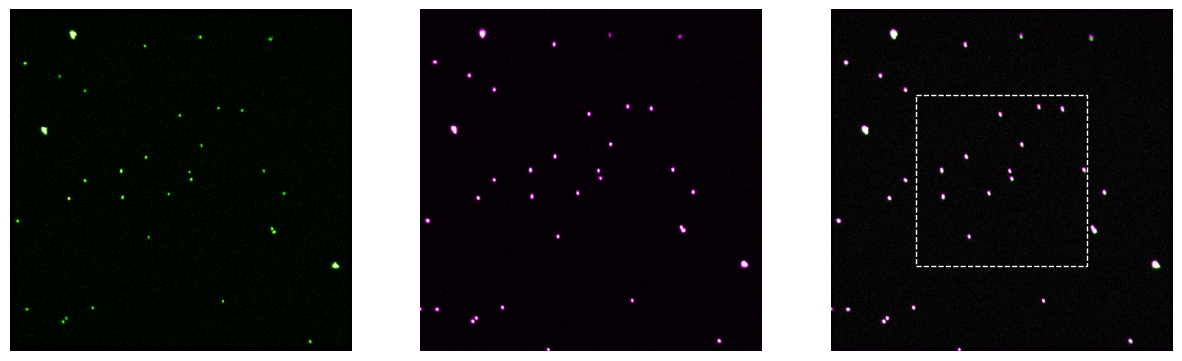

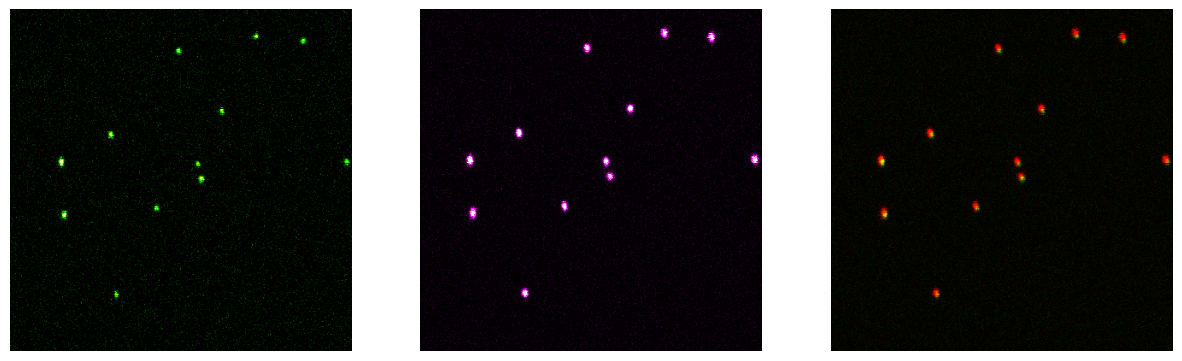

-------
itk::simple::TranslationTransform
 TranslationTransform (0x563b097f07e0)
   RTTI typeinfo:   itk::TranslationTransform<double, 2u>
   Reference Count: 2
   Modified Time: 68808
   Debug: Off
   Object Name: 
   Observers: 
     none
   Offset: [1.42298, 2.55019]

(800, 800)


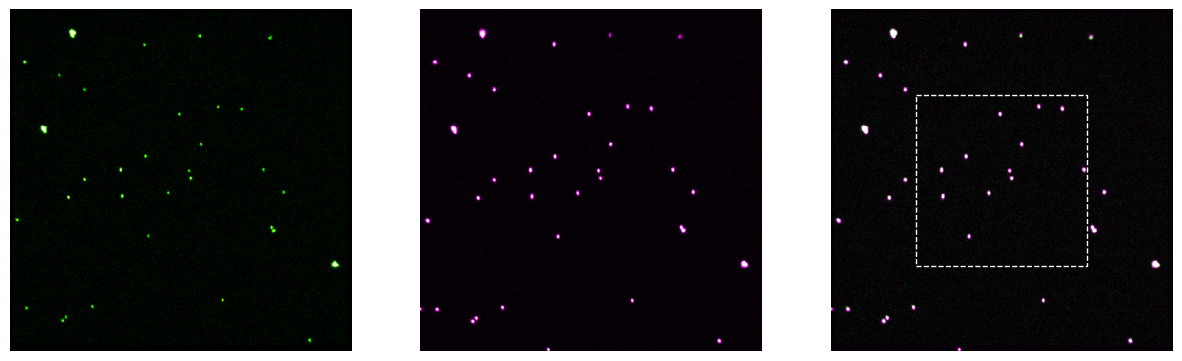

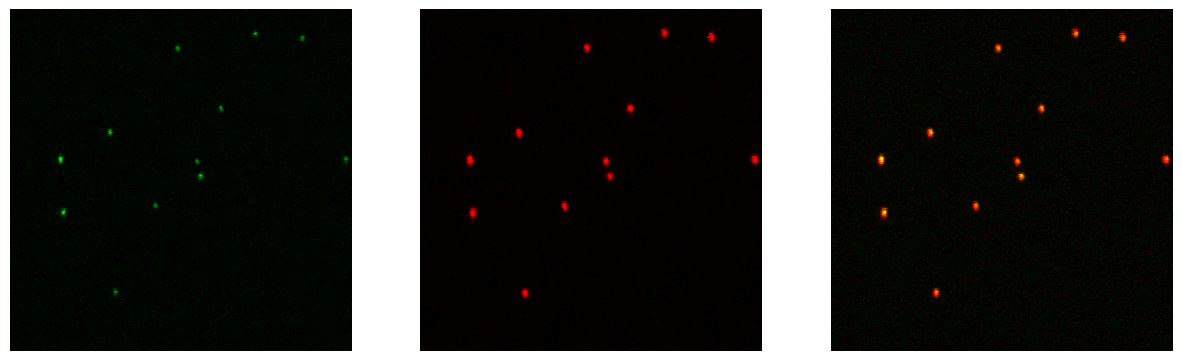

In [130]:
# import random
# random.shuffle(files)
# for file in files:
images = numpy.stack(
    [tifffile.imread(files[1]), tifffile.imread(files[0])]
).squeeze()
images = numpy.stack([registered_image_copy, images[1]]).squeeze()

cy, cx = numpy.array(images[0].shape) // 2
# images = images[:, cy-256:cy+256, cx-256:cx+256]
images = images.astype("float32")


# images[0] = numpy.roll(images[0], shift=0, axis=1)

print(images.shape)

cy, cx = numpy.array(images[0].shape) // 2
# cy, cx = images[0].shape[0] - 256, images[0].shape[1] - 256
slc = tuple(
    slice(max(0, c - 200), min(s, c + 200)) for c, s in zip((cy, cx), images[0].shape)
)

from matplotlib import patches
rect = patches.Rectangle((slc[1].start, slc[0].start), slc[1].stop - slc[1].start, slc[0].stop - slc[0].start, linewidth=1, edgecolor='w', facecolor='none', linestyle='--')

fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(make_composite(images[0:1], ["Green Hot"], ranges=[(0, 1)]))
axes[1].imshow(make_composite(images[1:2], ["Magenta Hot"], ranges=[(0, 0.7)]))
axes[2].imshow(make_composite(images, ["Green Hot", "Magenta Hot"], ranges=[(0, 1), (0, 0.7)]))
axes[2].add_patch(rect)
for ax in axes:
    ax.axis('off')
pyplot.show()

fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(make_composite(images[0:1, slc[0], slc[1]], ["Green Hot"], ranges=[(0, 1)]))
axes[1].imshow(make_composite(images[1:2, slc[0], slc[1]], ["Magenta Hot"], ranges=[(0, 0.7)]))
axes[2].imshow(make_composite(images[:, slc[0], slc[1]], ["green", "red"], ranges=[(0, 1), (0, 0.7)]))
for ax in axes:
    ax.axis('off')
pyplot.show()

moving_image = sitk.GetImageFromArray(images[0])
fixed_image = sitk.GetImageFromArray(images[1])


R = sitk.ImageRegistrationMethod()
R.SetMetricAsMeanSquares()
# R.SetOptimizerAsRegularStepGradientDescent(learningRate=1.0, minStep=1e-4, numberOfIterations=200)
R.SetOptimizerAsLBFGSB()
R.SetInitialTransform(sitk.TranslationTransform(fixed_image.GetDimension()))
R.SetInterpolator(sitk.sitkLinear)
R.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration)
tx1 = R.Execute(fixed_image, moving_image)
print("-------")
print(tx1)

resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(fixed_image)
resampler.SetInterpolator(sitk.sitkNearestNeighbor)
resampler.SetTransform(tx1)
out = resampler.Execute(moving_image)

registered_image = sitk.GetArrayFromImage(out)
print(registered_image.shape)

fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(make_composite(registered_image[None, ...], ["Green Hot"], ranges=[(0, 1)]))
axes[1].imshow(make_composite(images[1:2], ["Magenta Hot"], ranges=[(0, 0.7)]))
axes[2].imshow(make_composite(numpy.stack([registered_image, images[1]]), ["Green Hot", "Magenta Hot"], ranges=[(0, 1), (0, 0.7)]))


tifffile.imwrite("/home-local2/tmp/registered2.tif", numpy.stack([registered_image, images[1]]).astype("float32"))

rect = patches.Rectangle((slc[1].start, slc[0].start), slc[1].stop - slc[1].start, slc[0].stop - slc[0].start, linewidth=1, edgecolor='w', facecolor='none', linestyle='--')
axes[2].add_patch(rect)
for ax in axes:
    ax.axis('off')
pyplot.show()

fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(make_composite(registered_image[slc[0], slc[1]][None, ...], ["green"], ranges=[(0, 1)]))
axes[1].imshow(make_composite(images[1:2, slc[0], slc[1]], ["red"], ranges=[(0, 0.7)]))
axes[2].imshow(make_composite(numpy.stack([registered_image[slc[0], slc[1]], images[1, slc[0], slc[1]]], axis=0), ["green", "red"], ranges=[(0, 1), (0, 0.7)]))
for ax in axes:
    ax.axis('off')
pyplot.show()